# Análisis de trayectoria de cámaras del dataset

Este notebook analiza la trayectoria de cámaras utilizada como base común para los tres procesos del proyecto:

```text
mismo dataset / misma trayectoria de cámara
→ COLMAP / Fotogrametría
→ Nerfacto / NeRF
→ Splatfacto / Gaussian Splatting
```

El objetivo no es evaluar todavía la calidad visual del render, sino caracterizar la **captura**:

- cantidad de cámaras / frames;
- trayectoria en planta;
- distribución espacial;
- altura relativa;
- distancia entre cámaras consecutivas;
- orientación de cámaras;
- detección de saltos bruscos;
- cobertura espacial del recorrido.

In [1]:
!pip -q install pandas numpy matplotlib pillow tqdm reportlab

import json
import math
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

print("Dependencias listas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.1 MB/s eta 0:00:00
Dependencias listas.


## 1. Montar Google Drive y localizar `transforms.json`

El notebook intenta encontrar automáticamente el archivo `transforms.json`.

Rutas esperadas:

```text
/content/drive/MyDrive/colab/transforms.json
/content/drive/MyDrive/colab/datasets/transforms.json
/content/drive/MyDrive/colab/ns-data-drone/transforms.json
```

Si lo tenés en otra carpeta, ajustá manualmente `TRANSFORMS_PATH`.

In [20]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets")
OUTPUT_DIR = PROJECT_DIR / "analisis-de-camaras-output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    PROJECT_DIR / "transforms.json",
]

TRANSFORMS_PATH = None
for p in candidate_paths:
    if p.exists():
        TRANSFORMS_PATH = p
        break

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

if TRANSFORMS_PATH is None:
    print("No encontré transforms.json automáticamente.")
    print("Ajustá TRANSFORMS_PATH manualmente en la siguiente celda.")
else:
    print("TRANSFORMS_PATH:", TRANSFORMS_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets
OUTPUT_DIR: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/analisis-de-camaras-output
TRANSFORMS_PATH: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/transforms.json


In [6]:
# Si la celda anterior no encontró el archivo, descomentá y editá esta línea:
# TRANSFORMS_PATH = Path("/content/drive/MyDrive/colab/ns-data-drone/transforms.json")

assert TRANSFORMS_PATH is not None, "Definí TRANSFORMS_PATH manualmente."
assert Path(TRANSFORMS_PATH).exists(), f"No existe: {TRANSFORMS_PATH}"

with open(TRANSFORMS_PATH, "r", encoding="utf-8") as f:
    transforms = json.load(f)

print("Archivo cargado:", TRANSFORMS_PATH)
print("Claves principales:", list(transforms.keys()))
print("Cantidad de frames:", len(transforms.get("frames", [])))

Archivo cargado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/transforms.json
Claves principales: ['w', 'h', 'fl_x', 'fl_y', 'cx', 'cy', 'k1', 'k2', 'p1', 'p2', 'camera_model', 'frames', 'applied_transform', 'ply_file_path']
Cantidad de frames: 707


## 2. Extraer posiciones y orientaciones de cámara

En Nerfstudio, cada frame suele tener una matriz `transform_matrix` de 4×4. La traslación de esa matriz representa la posición de cámara en coordenadas del dataset.

La orientación se estima a partir del eje forward de cámara. En la convención habitual de cámaras tipo OpenGL, el vector de mirada corresponde a `-Z` local transformado al mundo.

In [7]:
frames = transforms["frames"]

rows = []
bad_frames = []

for idx, fr in enumerate(frames):
    if "transform_matrix" not in fr:
        bad_frames.append((idx, fr.get("file_path", "")))
        continue

    T = np.array(fr["transform_matrix"], dtype=float)

    if T.shape != (4, 4):
        bad_frames.append((idx, fr.get("file_path", "")))
        continue

    R = T[:3, :3]
    t = T[:3, 3]

    forward = -R[:, 2]
    up = R[:, 1]
    right = R[:, 0]

    forward = forward / (np.linalg.norm(forward) + 1e-9)
    up = up / (np.linalg.norm(up) + 1e-9)
    right = right / (np.linalg.norm(right) + 1e-9)

    yaw_xz = math.degrees(math.atan2(forward[0], forward[2]))
    pitch_y = math.degrees(math.asin(np.clip(forward[1], -1, 1)))

    rows.append({
        "frame_index": idx,
        "file_path": fr.get("file_path", ""),
        "file_name": Path(fr.get("file_path", "")).name,
        "x": t[0],
        "y": t[1],
        "z": t[2],
        "forward_x": forward[0],
        "forward_y": forward[1],
        "forward_z": forward[2],
        "up_x": up[0],
        "up_y": up[1],
        "up_z": up[2],
        "right_x": right[0],
        "right_y": right[1],
        "right_z": right[2],
        "yaw_xz_deg": yaw_xz,
        "pitch_y_deg": pitch_y,
    })

cameras_df = pd.DataFrame(rows)
cameras_df.to_csv(OUTPUT_DIR / "camera_poses.csv", index=False)

print("Frames totales:", len(frames))
print("Cámaras válidas:", len(cameras_df))
print("Frames problemáticos:", len(bad_frames))
cameras_df.head()

Frames totales: 707
Cámaras válidas: 707
Frames problemáticos: 0


,frame_index,file_path,file_name,x,y,z,forward_x,forward_y,forward_z,up_x,up_y,up_z,right_x,right_y,right_z,yaw_xz_deg,pitch_y_deg
0,0,images/frame_00707.jpg,frame_00707.jpg,-1.573613,-0.169681,-0.832550,0.890568,-0.454630,-0.014145,0.013085,-0.005477,0.999899,-0.454662,-0.890664,0.001072,90.909937,-27.041121
1,1,images/frame_00706.jpg,frame_00706.jpg,-1.581150,-0.168727,-0.834626,0.890595,-0.454585,-0.013921,0.012893,-0.005362,0.999903,-0.454615,-0.890687,0.001085,90.895548,-27.038226
2,2,images/frame_00705.jpg,frame_00705.jpg,-1.591104,-0.167779,-0.834737,0.890410,-0.454950,-0.013821,0.012850,-0.005227,0.999904,-0.454978,-0.890502,0.001191,90.889289,-27.061706
3,3,images/frame_00704.jpg,frame_00704.jpg,-1.575997,-0.157215,-0.829664,0.889862,-0.456002,-0.014378,0.013317,-0.005541,0.999896,-0.456034,-0.889961,0.001142,90.925702,-27.129438
4,4,images/frame_00703.jpg,frame_00703.jpg,-1.549628,-0.162493,-0.829535,0.889658,-0.456398,-0.014448,0.013306,-0.005716,0.999895,-0.456433,-0.889757,0.000988,90.930426,-27.154926


## 3. Métricas generales de trayectoria

Estas métricas no evalúan la calidad del modelo 3D. Evalúan la **estructura de captura**.

In [8]:
positions = cameras_df[["x", "y", "z"]].values

steps = np.linalg.norm(np.diff(positions, axis=0), axis=1)
path_length = float(steps.sum()) if len(steps) > 0 else 0.0

cameras_df["step_from_previous"] = np.nan
cameras_df.loc[1:, "step_from_previous"] = steps

bbox_min = positions.min(axis=0)
bbox_max = positions.max(axis=0)
bbox_size = bbox_max - bbox_min
center = positions.mean(axis=0)

summary_rows = [
    ["total_frames_in_transforms", len(frames)],
    ["valid_camera_poses", len(cameras_df)],
    ["path_length_dataset_units", path_length],
    ["bbox_min_x", bbox_min[0]],
    ["bbox_min_y", bbox_min[1]],
    ["bbox_min_z", bbox_min[2]],
    ["bbox_max_x", bbox_max[0]],
    ["bbox_max_y", bbox_max[1]],
    ["bbox_max_z", bbox_max[2]],
    ["bbox_size_x", bbox_size[0]],
    ["bbox_size_y", bbox_size[1]],
    ["bbox_size_z", bbox_size[2]],
    ["center_x", center[0]],
    ["center_y", center[1]],
    ["center_z", center[2]],
    ["step_mean", np.nanmean(cameras_df["step_from_previous"])],
    ["step_median", np.nanmedian(cameras_df["step_from_previous"])],
    ["step_std", np.nanstd(cameras_df["step_from_previous"])],
    ["step_min", np.nanmin(cameras_df["step_from_previous"])],
    ["step_max", np.nanmax(cameras_df["step_from_previous"])],
]

trajectory_summary = pd.DataFrame(summary_rows, columns=["metric", "value"])
trajectory_summary.to_csv(OUTPUT_DIR / "camera_trajectory_summary.csv", index=False)

trajectory_summary

,metric,value
0,total_frames_in_transforms,707.000000
1,valid_camera_poses,707.000000
2,path_length_dataset_units,89.779791
3,bbox_min_x,-4.406613
4,bbox_min_y,-4.538632
5,bbox_min_z,-2.192512
6,bbox_max_x,4.896361
7,bbox_max_y,4.357283
8,bbox_max_z,1.176560
9,bbox_size_x,9.302975


## 4. Detectar saltos bruscos en la trayectoria

In [9]:
step_mean = np.nanmean(cameras_df["step_from_previous"])
step_std = np.nanstd(cameras_df["step_from_previous"])

cameras_df["step_zscore"] = (cameras_df["step_from_previous"] - step_mean) / (step_std + 1e-9)

JUMP_ZSCORE_THRESHOLD = 3.0

jumps_df = cameras_df[
    cameras_df["step_zscore"].abs() >= JUMP_ZSCORE_THRESHOLD
].copy()

top_steps_df = cameras_df.sort_values("step_from_previous", ascending=False).head(20).copy()

jumps_df.to_csv(OUTPUT_DIR / "camera_trajectory_detected_jumps.csv", index=False)
top_steps_df.to_csv(OUTPUT_DIR / "camera_trajectory_top_steps.csv", index=False)

print("Saltos detectados por z-score:", len(jumps_df))
top_steps_df[["frame_index", "file_name", "step_from_previous", "step_zscore"]].head(20)

Saltos detectados por z-score: 4


,frame_index,file_name,step_from_previous,step_zscore
166,166,frame_00257.jpg,8.847770,19.510222
423,423,frame_00258.jpg,6.341683,13.903463
296,296,frame_00059.jpg,3.184597,6.840253
355,355,frame_00060.jpg,2.130923,4.482915
103,103,frame_00604.jpg,0.703907,1.290315
510,510,frame_00345.jpg,0.695308,1.271077
509,509,frame_00344.jpg,0.678913,1.234398
102,102,frame_00605.jpg,0.651926,1.174020
580,580,frame_00415.jpg,0.633782,1.133428
104,104,frame_00603.jpg,0.606856,1.073188


## 5. Visualizaciones de trayectoria

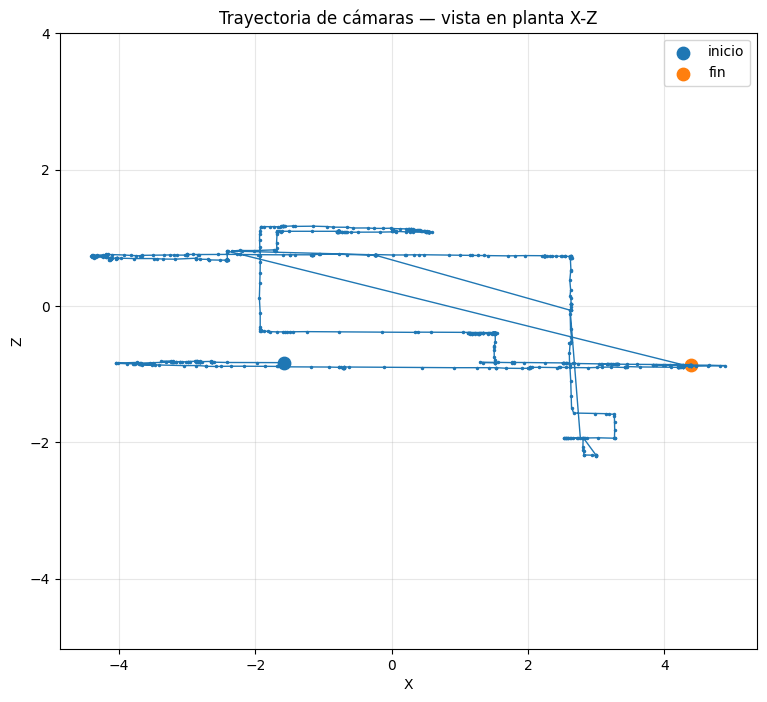

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_top_view_xz.png


In [10]:
plt.figure(figsize=(9, 8))
plt.plot(cameras_df["x"], cameras_df["z"], linewidth=1, marker=".", markersize=3)
plt.scatter(cameras_df["x"].iloc[0], cameras_df["z"].iloc[0], s=80, label="inicio")
plt.scatter(cameras_df["x"].iloc[-1], cameras_df["z"].iloc[-1], s=80, label="fin")
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Trayectoria de cámaras — vista en planta X-Z")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
out = OUTPUT_DIR / "camera_trajectory_top_view_xz.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

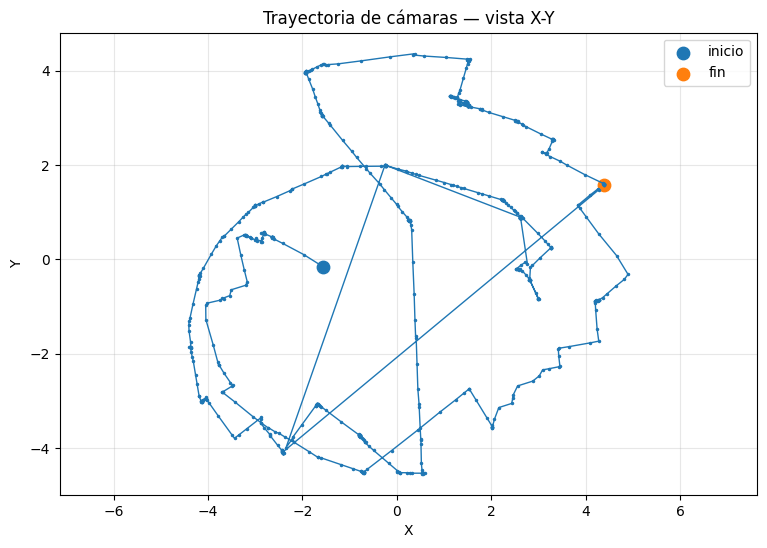

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_xy.png


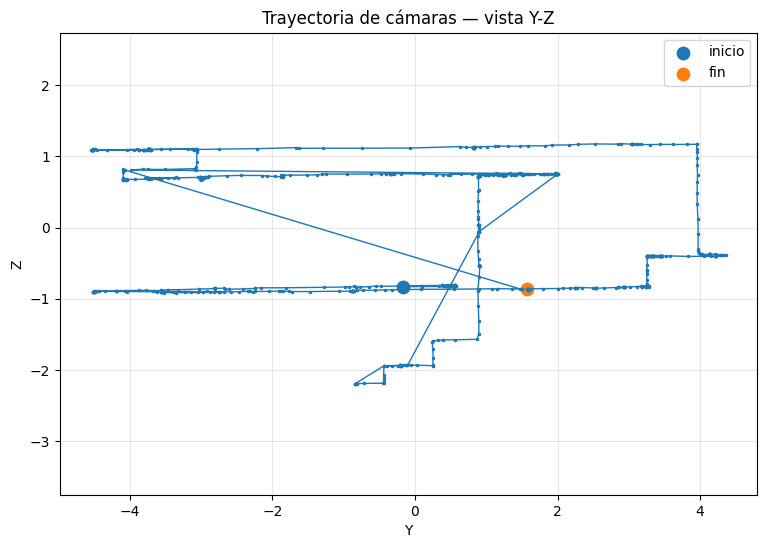

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_yz.png


In [11]:
for a, b, title, filename in [
    ("x", "y", "Trayectoria de cámaras — vista X-Y", "camera_trajectory_xy.png"),
    ("y", "z", "Trayectoria de cámaras — vista Y-Z", "camera_trajectory_yz.png"),
]:
    plt.figure(figsize=(9, 6))
    plt.plot(cameras_df[a], cameras_df[b], linewidth=1, marker=".", markersize=3)
    plt.scatter(cameras_df[a].iloc[0], cameras_df[b].iloc[0], s=80, label="inicio")
    plt.scatter(cameras_df[a].iloc[-1], cameras_df[b].iloc[-1], s=80, label="fin")
    plt.xlabel(a.upper())
    plt.ylabel(b.upper())
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    out = OUTPUT_DIR / filename
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

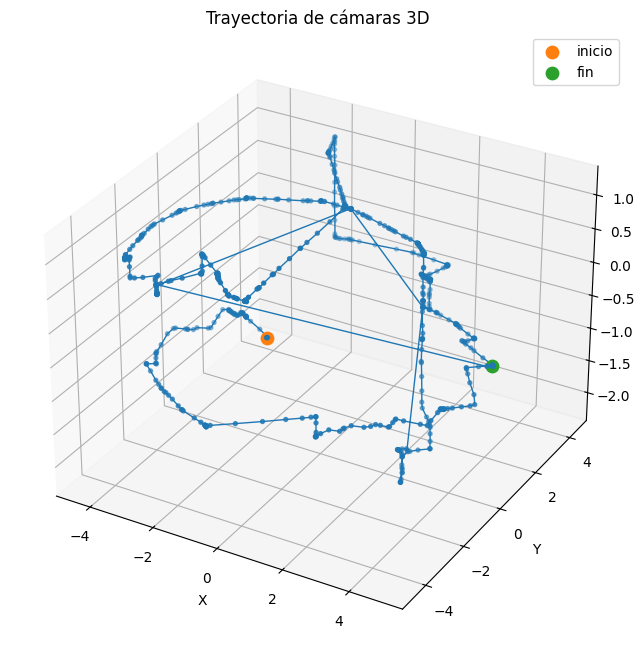

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_3d.png


In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(cameras_df["x"], cameras_df["y"], cameras_df["z"], linewidth=1)
ax.scatter(cameras_df["x"], cameras_df["y"], cameras_df["z"], s=8)

ax.scatter(cameras_df["x"].iloc[0], cameras_df["y"].iloc[0], cameras_df["z"].iloc[0], s=80, label="inicio")
ax.scatter(cameras_df["x"].iloc[-1], cameras_df["y"].iloc[-1], cameras_df["z"].iloc[-1], s=80, label="fin")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Trayectoria de cámaras 3D")
ax.legend()

out = OUTPUT_DIR / "camera_trajectory_3d.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

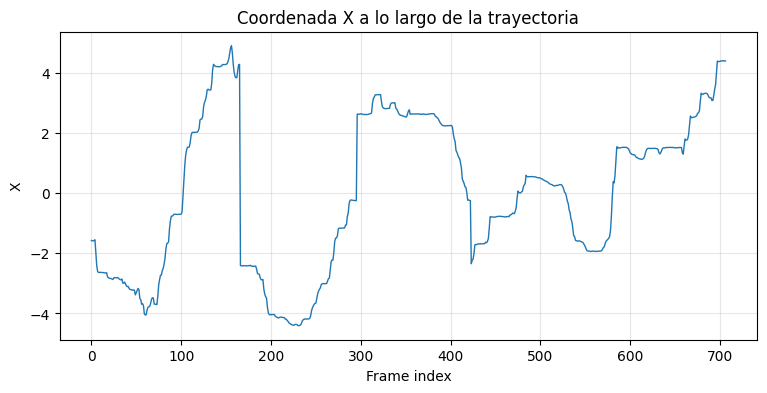

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_coordinate_x_over_time.png


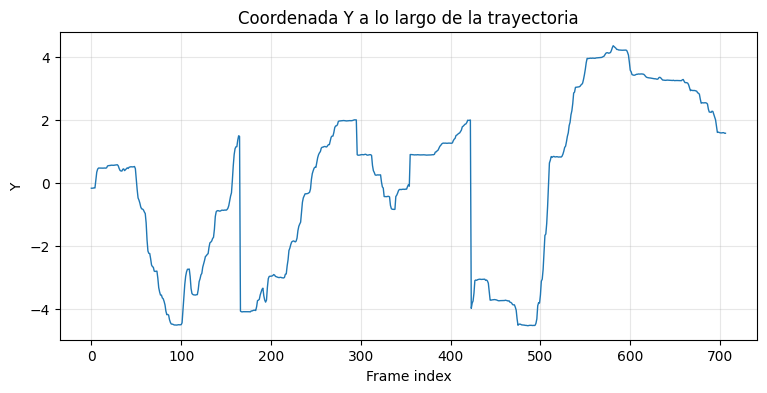

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_coordinate_y_over_time.png


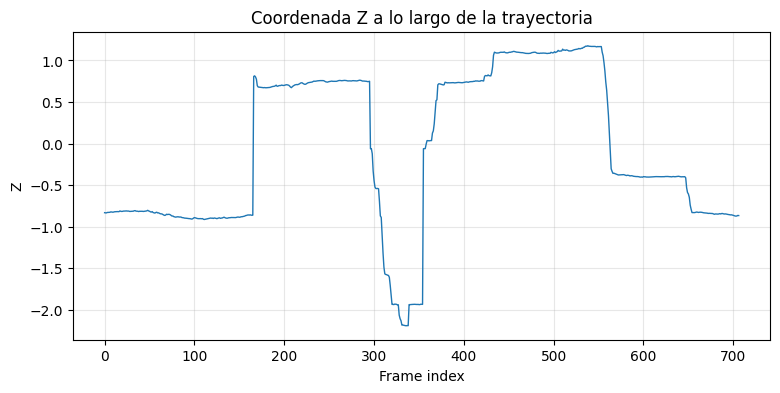

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_coordinate_z_over_time.png


In [13]:
for axis in ["x", "y", "z"]:
    plt.figure(figsize=(9, 4))
    plt.plot(cameras_df["frame_index"], cameras_df[axis], linewidth=1)
    plt.xlabel("Frame index")
    plt.ylabel(axis.upper())
    plt.title(f"Coordenada {axis.upper()} a lo largo de la trayectoria")
    plt.grid(True, alpha=0.3)
    out = OUTPUT_DIR / f"camera_coordinate_{axis}_over_time.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

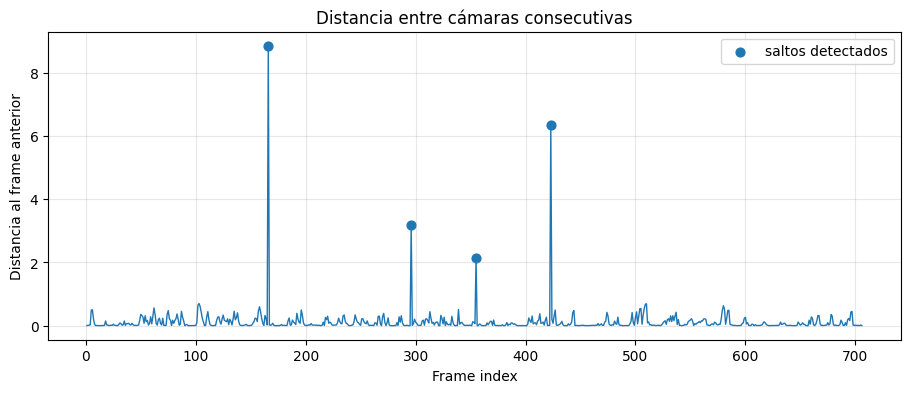

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_step_distance_over_time.png


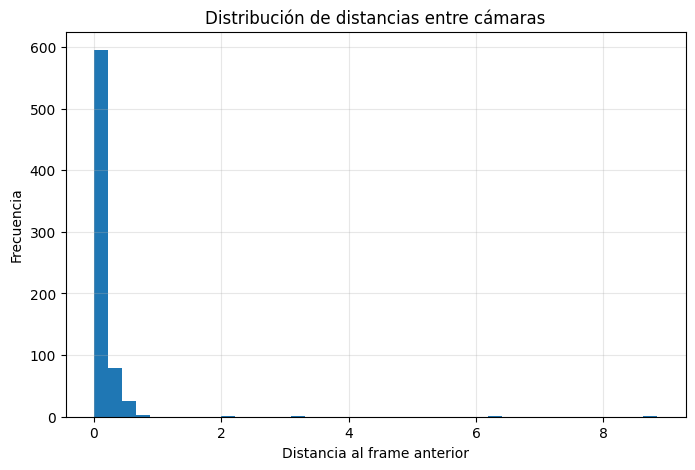

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_step_distance_histogram.png


In [14]:
plt.figure(figsize=(11, 4))
plt.plot(cameras_df["frame_index"], cameras_df["step_from_previous"], linewidth=1)
plt.xlabel("Frame index")
plt.ylabel("Distancia al frame anterior")
plt.title("Distancia entre cámaras consecutivas")
plt.grid(True, alpha=0.3)

if len(jumps_df) > 0:
    plt.scatter(jumps_df["frame_index"], jumps_df["step_from_previous"], s=40, label="saltos detectados")
    plt.legend()

out = OUTPUT_DIR / "camera_step_distance_over_time.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

plt.figure(figsize=(8, 5))
plt.hist(cameras_df["step_from_previous"].dropna(), bins=40)
plt.xlabel("Distancia al frame anterior")
plt.ylabel("Frecuencia")
plt.title("Distribución de distancias entre cámaras")
plt.grid(True, alpha=0.3)
out = OUTPUT_DIR / "camera_step_distance_histogram.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

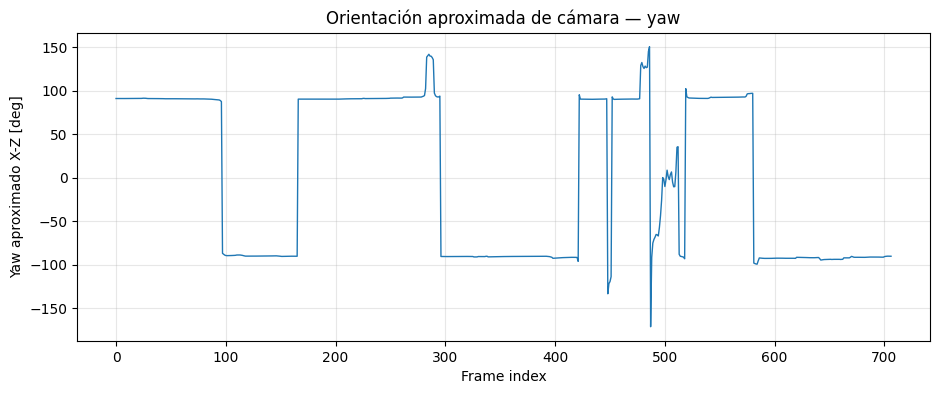

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_yaw_over_time.png


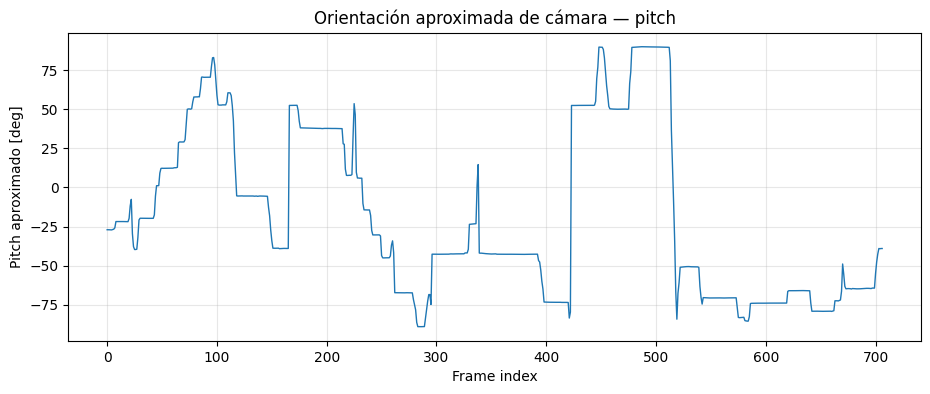

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_pitch_over_time.png


In [15]:
plt.figure(figsize=(11, 4))
plt.plot(cameras_df["frame_index"], cameras_df["yaw_xz_deg"], linewidth=1)
plt.xlabel("Frame index")
plt.ylabel("Yaw aproximado X-Z [deg]")
plt.title("Orientación aproximada de cámara — yaw")
plt.grid(True, alpha=0.3)
out = OUTPUT_DIR / "camera_yaw_over_time.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

plt.figure(figsize=(11, 4))
plt.plot(cameras_df["frame_index"], cameras_df["pitch_y_deg"], linewidth=1)
plt.xlabel("Frame index")
plt.ylabel("Pitch aproximado [deg]")
plt.title("Orientación aproximada de cámara — pitch")
plt.grid(True, alpha=0.3)
out = OUTPUT_DIR / "camera_pitch_over_time.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

## 6. Muestreo train aproximado

Este bloque estima el split `train` de 90% para documentar por qué, en renders de dataset trajectory, pueden aparecer 637 frames a partir de un dataset original de 707 imágenes.

In [16]:
num_total = len(cameras_df)
train_fraction = 0.9
num_train_est = math.ceil(num_total * train_fraction)

split_df = pd.DataFrame([
    ["dataset_total", num_total],
    ["train_fraction_estimada", train_fraction],
    ["train_frames_estimados", num_train_est],
    ["eval_frames_estimados", num_total - num_train_est],
], columns=["metric", "value"])

split_df.to_csv(OUTPUT_DIR / "camera_dataset_split_estimate.csv", index=False)
split_df

,metric,value
0,dataset_total,707.0
1,train_fraction_estimada,0.9
2,train_frames_estimados,637.0
3,eval_frames_estimados,70.0


## 7. Generar reporte PDF

In [19]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage, PageBreak

PDF_PATH = PROJECT_DIR / "camera_trajectory_report.pdf"
PDF_COPY_PATH = OUTPUT_DIR / "camera_trajectory_report.pdf"

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="TitleCenter", parent=styles["Title"], alignment=TA_CENTER, fontSize=18, leading=22, spaceAfter=16))
styles.add(ParagraphStyle(name="SectionTitle", parent=styles["Heading1"], fontSize=14, leading=17, spaceBefore=10, spaceAfter=8))
styles.add(ParagraphStyle(name="BodySmall", parent=styles["BodyText"], fontSize=9, leading=12, spaceAfter=6))

def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def make_table_pdf(df, font_size=7, max_rows=None):
    d = df.copy()
    if max_rows is not None:
        d = d.head(max_rows)
    for col in d.columns:
        if pd.api.types.is_float_dtype(d[col]):
            d[col] = d[col].round(4)
    data = [list(d.columns)] + d.astype(str).values.tolist()
    data = [[clean_text(cell) for cell in row] for row in data]
    table = Table(data, repeatRows=1)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, -1), font_size),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.whitesmoke]),
    ]))
    return table

def image_for_pdf(path, max_width=17*cm, max_height=11*cm):
    path = Path(path)
    if not path.exists():
        return None
    img = RLImage(str(path))
    iw, ih = img.imageWidth, img.imageHeight
    scale = min(max_width / iw, max_height / ih)
    img.drawWidth = iw * scale
    img.drawHeight = ih * scale
    return img

doc = SimpleDocTemplate(str(PDF_PATH), pagesize=A4, rightMargin=1.5*cm, leftMargin=1.5*cm, topMargin=1.5*cm, bottomMargin=1.5*cm)

story = []
story.append(Paragraph("Análisis de trayectoria de cámaras", styles["TitleCenter"]))
story.append(Paragraph("Dataset común para Fotogrametría, NeRF/Nerfacto y Gaussian Splatting/Splatfacto", styles["BodySmall"]))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("1. Objetivo", styles["SectionTitle"]))
story.append(Paragraph(
    "Este reporte caracteriza la trayectoria de cámaras utilizada como base común para los tres procesos del proyecto: "
    "fotogrametría/COLMAP, NeRF/Nerfacto y Gaussian Splatting/Splatfacto. El objetivo es documentar que la comparación "
    "posterior de outputs parte de una misma secuencia de captura y de un mismo conjunto de poses estimadas.",
    styles["BodySmall"]
))

story.append(Paragraph("2. Resumen numérico", styles["SectionTitle"]))
story.append(make_table_pdf(trajectory_summary, font_size=7))
story.append(Spacer(1, 0.3*cm))

story.append(Paragraph("3. Estimación de split de dataset", styles["SectionTitle"]))
story.append(make_table_pdf(split_df, font_size=7))
story.append(Spacer(1, 0.3*cm))

story.append(PageBreak())

story.append(Paragraph("4. Trayectoria espacial", styles["SectionTitle"]))
for title, filename in [
    ("Vista en planta X-Z", "camera_trajectory_top_view_xz.png"),
    ("Vista X-Y", "camera_trajectory_xy.png"),
    ("Vista Y-Z", "camera_trajectory_yz.png"),
    ("Trayectoria 3D", "camera_trajectory_3d.png"),
]:
    img = image_for_pdf(OUTPUT_DIR / filename)
    if img is not None:
        story.append(Paragraph(title, styles["BodySmall"]))
        story.append(img)
        story.append(Spacer(1, 0.25*cm))

story.append(PageBreak())

story.append(Paragraph("5. Continuidad de trayectoria", styles["SectionTitle"]))
for title, filename in [
    ("Distancia entre cámaras consecutivas", "camera_step_distance_over_time.png"),
    ("Histograma de distancia entre cámaras", "camera_step_distance_histogram.png"),
]:
    img = image_for_pdf(OUTPUT_DIR / filename)
    if img is not None:
        story.append(Paragraph(title, styles["BodySmall"]))
        story.append(img)
        story.append(Spacer(1, 0.25*cm))

story.append(Paragraph("Saltos principales", styles["SectionTitle"]))
story.append(make_table_pdf(top_steps_df[["frame_index", "file_name", "step_from_previous", "step_zscore"]], font_size=6, max_rows=15))

story.append(PageBreak())

story.append(Paragraph("6. Coordenadas y orientación", styles["SectionTitle"]))
for title, filename in [
    ("Coordenada X en el tiempo", "camera_coordinate_x_over_time.png"),
    ("Coordenada Y en el tiempo", "camera_coordinate_y_over_time.png"),
    ("Coordenada Z en el tiempo", "camera_coordinate_z_over_time.png"),
    ("Yaw aproximado", "camera_yaw_over_time.png"),
    ("Pitch aproximado", "camera_pitch_over_time.png"),
]:
    img = image_for_pdf(OUTPUT_DIR / filename)
    if img is not None:
        story.append(Paragraph(title, styles["BodySmall"]))
        story.append(img)
        story.append(Spacer(1, 0.25*cm))

story.append(PageBreak())

story.append(Paragraph("7. Conclusión metodológica", styles["SectionTitle"]))
story.append(Paragraph(
    "El análisis de trayectoria permite documentar la base de captura usada por el pipeline. "
    "A diferencia de las métricas visuales o geométricas de cada output, este análisis describe la condición de entrada compartida. "
    "Por lo tanto, ayuda a sostener que las diferencias observadas entre fotogrametría, Nerfacto y Splatfacto no provienen de datasets distintos, "
    "sino de la forma en que cada método representa, optimiza y exporta la misma secuencia de cámaras.",
    styles["BodySmall"]
))

doc.build(story)

# shutil.copy2(PDF_PATH, PDF_COPY_PATH)

print("PDF generado:")
print(" -", PDF_PATH)
print(" -", PDF_COPY_PATH)

PDF generado:
 - /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_report.pdf
 - /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/camera_trajectory_report.pdf


## 8. Exportar ZIP de resultados

In [ ]:
zip_path = PROJECT_DIR / "camera_trajectory_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("ZIP generado:", zip_path)

from google.colab import files
files.download(str(zip_path))